In [1]:
import sys
import os

# 1. Safely change the current working directory to the main project root.
# This ensures that when scenario_class looks for the "data" folder, it actually finds it.
# We check if we are in 'jupyter_scripts' first so running this cell multiple times doesn't keep moving up directories.
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    os.chdir('..')

# 2. Add the 'model_code' folder to sys.path so Python can find your classes
module_path = os.path.abspath('model_code')
if module_path not in sys.path:
    sys.path.append(module_path)

# 3. Now your imports AND file reading will work correctly
from scenario_class import Scenario
from plots_class import Plots
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

# --- Your parameters and execution remain exactly the same below ---

scenario_params = {"end_year": 2100, # end year of convergence not for the whole trajectory which is now always 2100
                   "income_goal": 20000, # in terms of 2017 USD PPP disposable household income per capita (the delineation between income and cons. exp is not necessarily clear)
                   "carbon_budget": 1150*0.95 - 2*35, # in terms of GtCO2 that is gigatons of CO2   and times 95% because 95% population coverage     
                   #"hysteresis_tech_progress": 0.01, # this is a growth rate, so between 0 and 1, which only applies if tech_hysteresis_assumption is on
                   "gdp_assumption": "constant_ratio", # this is a string and either (1) constant_ratio or (2) model_ratio for details see the scenario_class.py file         
                   "pop_growth_assumption": "semi_log_model", # this is a string and either (1) UN_medium, (2) semi_log_model for details see the scenario_class.py file  
                   "tech_evolution_assumption": "plausible", # this is a string and either (1) plausible or (2) necessary for details see the scenario_class.py file
                   "tech_hysteresis_assumption": "optimistic_degrowth", # this is a string and either (1) optimistic_degrowth or (2) pessimistic_degrowth or (3) off for details see the scenario_class.py file 
                   "steady_state_high_income_assumption": "off", # this is a string and either (1) on or (2) off or (3) on_with_growth for details see the scenario_class.py file
                   "k": 0.05,
                   "t0": 2060,
                   "final_improvement_rate": -0.05,
                   "population_hysteresis_assumption": "off", # this is a string and either (1) on or (2) off for details see the scenario_class.py file      
                   "run_until_2100": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_assumption": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_level_2100": 5, #  in gigatons of CO2 per year, so 0.95 means 950 million tons of CO2 per year
                     # --- ADD THESE NEW PARAMETERS HERE ---
                   "elasticity_assumption": "off", # Options: "off", "constant", "income_dependent"
                   "elasticity_value": 1.2                                # Only used if assumption is "constant"
            }


scenario_1 = Scenario(scenario_params)
#test = scenario_1.raw_data
scenario_1.compute_country_scenario_params()
print(scenario_1.compute_average_global_growth_rate())
scenario_1.run()

#scenario_params2 =  {"end_year": 2080,
                    #"income_goal": 30000, # in terms of 2017 USD PPP disposable household income per capita (the delineation between income and cons. exp is not necessarily clear)
                  #  "carbon_budget": 1150*0.95 - 2*35, # in terms of GtCO2 that is gigatons of CO2       
                  #   "hysteresis_tech_progress": 0.01, # this is a growth rate, so between 0 and 1, which only applies if tech_hysteresis_assumption is on 
                  #  "gdp_assumption": "constant_ratio", # this is a string and either (1) constant_ratio or (2) model_ratio for details see the scenario_class.py file         
                  #  "pop_growth_assumption": "semi_log_model", # this is a string and either (1) UN_medium, (2) semi_log_model (3) semi_log_model_elasticity for details see the scenario_class.py file  
                  #  "tech_evolution_assumption": "plausible", # this is a string and either (1) plausible or (2) necessary for details see the scenario_class.py file
                   # "tech_hysteresis_assumption": "off", # this is a string and either (1) on or (2) off for details see the scenario_class.py file 
                   # "steady_state_high_income_assumption": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                    #"k": 0.05,
                   # "t0": 2080,
                   # "final_improvement_rate": -0.05,
                   # "population_hysteresis_assumption": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   # "run_until_2100": "on", 
                    #"run_until_2100": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                    #"cdr_assumption": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                    #"cdr_level_2100": 10 #  in gigatons of CO2 per year, so 0.95 means 950 million tons of CO2 per year}
 #}


 #scenario_2 = Scenario(scenario_params2)
 #scenario_2.compute_country_scenario_params()
 #print(scenario_2.compute_average_global_growth_rate())
 #scenario_2.run()

0.014112236619956198


# print a few quantities to check if the model is working

In [2]:
# print a few quantities to check if the model is working


sum_gdp = 0
for country in scenario_1.countries:
    sum_gdp += scenario_1.countries[country].gdp_trajectory[2100]
    print(country, scenario_1.countries[country].gdp_trajectory[2100])

#do the same for the population
sum_pop = 0
for country in scenario_1.countries:
    sum_pop += scenario_1.countries[country].population_trajectory[2100]
    print(country, scenario_1.countries[country].population_trajectory[2100])

# print the total gdp and population
print("Total gdp", sum_gdp)
print("Total population", sum_pop)

Angola 2950092342840.534
Albania 134516735514.57846
United Arab Emirates 260339726707.20312
Armenia 203623350895.85764
Australia 732609760644.9291
Austria 250552179641.24677
Burundi 923858037151.9445
Belgium 341998836830.7979
Benin 841590378365.2977
Burkina Faso 1369726726910.5232
Bangladesh 13566491951459.596
Bulgaria 221404215044.64282
Bosnia and Herzegovina 102533851172.68704
Belarus 427967722194.13025
Bolivia 427978470188.6176
Brazil 9509703388565.809
Bhutan 35215079148.94239
Botswana 182364670856.79807
Central African Republic 392944309438.34454
Canada 1097803841368.2383
Switzerland 245948221088.48056
Chile 788897753809.8821
China 76015482060366.14
Cote d'Ivoire 1832797937192.4282
Cameroon 1669500118267.4587
Congo, Dem. Rep. 6996952795612.172
Congo, Rep. 527577182413.6067
Colombia 2745067506173.7183
Comoros 45393889383.85067
Cabo Verde 30714251136.998238
Costa Rica 221004888306.8908
Cyprus 36470352729.19681
Czech Republic 375117968908.4261
Germany 2424505251485.2046
Denmark 169173

Text(0, 0.5, 'Average CAGR from 2023 to 2100')

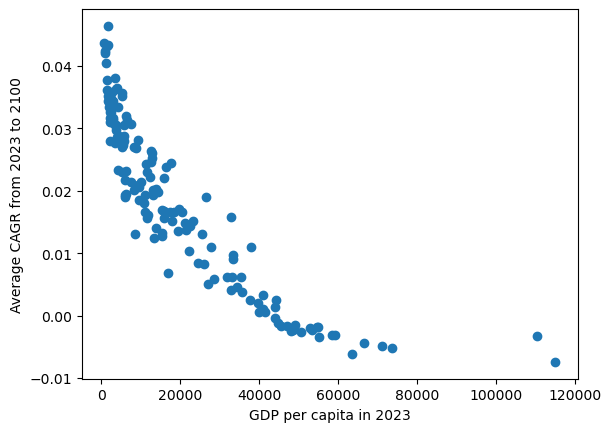

In [3]:
# loop over all countries and find self.cagr_average for all of them and plot them on a scatter plot against the gdp per capita in 2022
gdp_per_capita_2023 = []
cagr_average = []
for country in scenario_1.countries:
    gdp_per_capita_2023.append(scenario_1.countries[country].gdp_trajectory[2023] / scenario_1.countries[country].population_trajectory[2022])
    cagr_average.append(scenario_1.countries[country].cagr_average)
plt.scatter(gdp_per_capita_2023, cagr_average)
plt.xlabel("GDP per capita in 2023")
plt.ylabel("Average CAGR from 2023 to 2100")

### Plot global quantities as a first check

Global GDP per Capita from 2022 to 2100:
Global GDP per Capita in 2022: $17,444.91
Global GDP per Capita in 2100:   $56,359.86
CAGR from 2022 to 2100:  1.51%



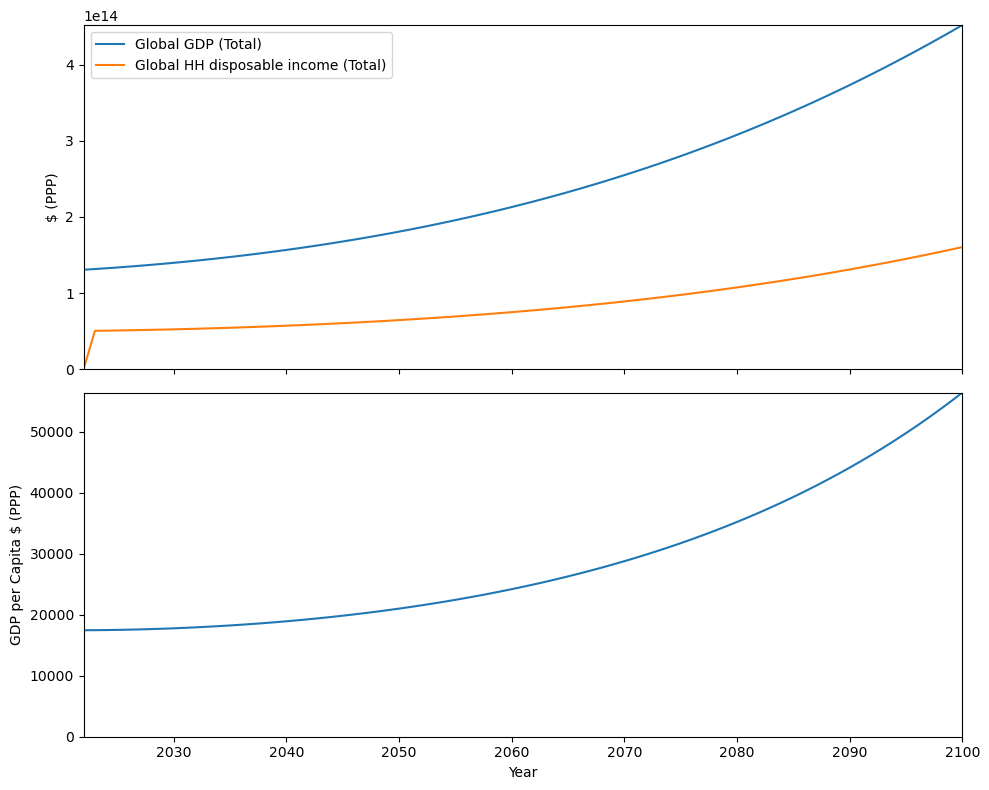

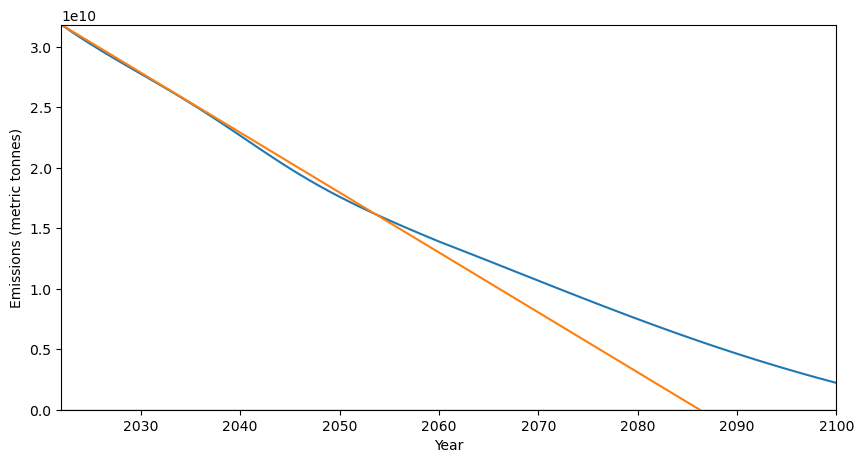

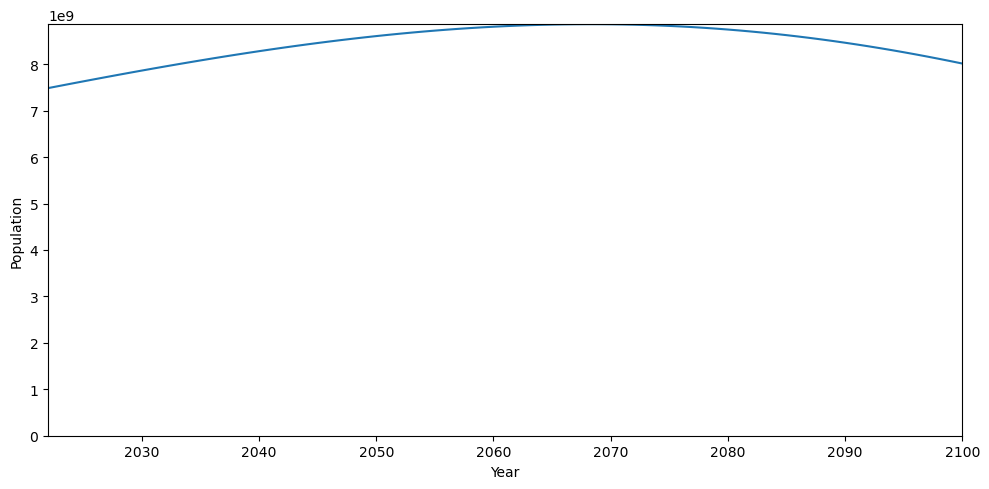

Global household income per capita in 2100: 20000.0


C:\Users\yoswald\AppData\Local\Temp\ipykernel_11796\4194694149.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  emission_trajectories[country.code] = country.emissions_trajectory
C:\Users\yoswald\AppData\Local\Temp\ipykernel_11796\4194694149.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  emission_trajectories[country.code] = country.emissions_trajectory
C:\Users\yoswald\AppData\Local\Temp\ipykernel_11796\4194694149.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

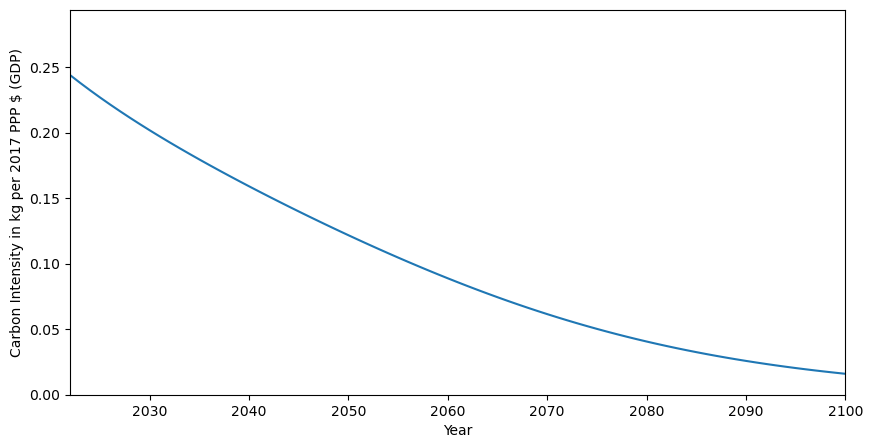

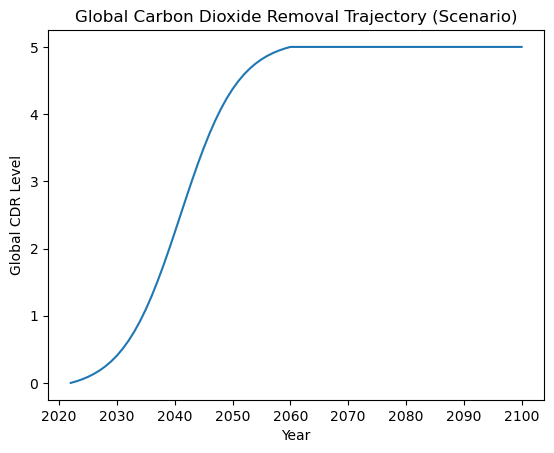

In [4]:


plotting_1 = Plots(scenario_1) # the current scenario must be passed to the plotting class to be able to plot the results
plotting_1.plot_global_economy()
plotting_1.plot_global_emissions()
plotting_1.plot_global_population()
plotting_1.plot_global_carbon_intensity()
if scenario_1.cdr_assumption == "on":

    plotting_1.plot_cdr_global_level_trajectory()


# store all the emission trajectories in a dataframe
emission_trajectories = pd.DataFrame()
for country in scenario_1.countries.values():
    emission_trajectories[country.code] = country.emissions_trajectory



# loop over all the countries in scenario_1 and compute total global hh income and then global hh income per capita
global_hh_income = 0
global_hh_income_per_capita = 0
for country in scenario_1.countries.values():
    global_hh_income += country.income_hh_trajectory[2100] * country.population_trajectory[2100]



global_hh_income_per_capita = global_hh_income / sum_pop
print("Global household income per capita in 2100:", global_hh_income_per_capita)
    

### Compute with steady state



In [5]:
 #plotting_2 = Plots(scenario_2) # the current scenario must be passed to the plotting class to be able to plot the results
 #plotting_2.plot_global_economy()
 #plotting_2.plot_global_emissions()
 #plotting_2.plot_global_population()
 #plotting_2.plot_global_carbon_intensity()

# plot the population trajectories print population numbers at end of the trajectory


#### Compute global gdp per capita average

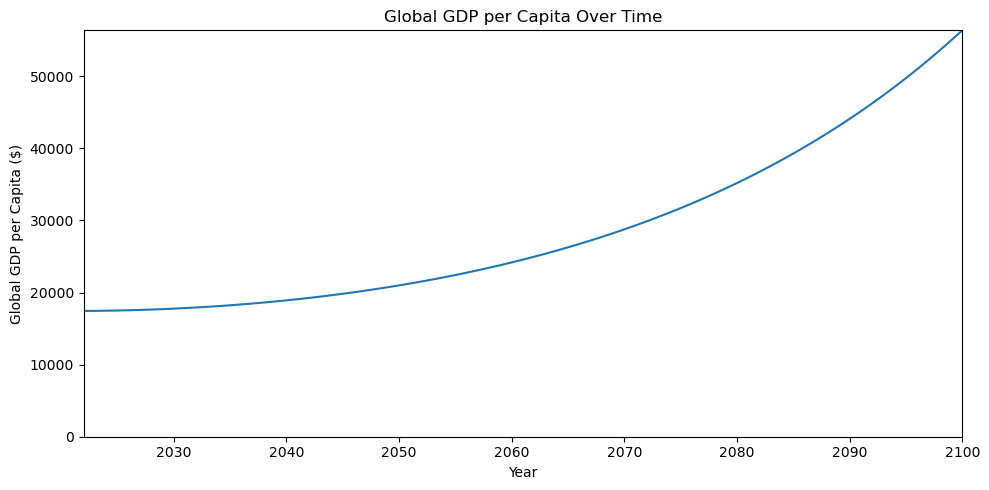

In [6]:
# Compute global gdp per capita average by dividing the global gdp by the global population for 2100 in the gdp trajectory and the pop trajectory
plotting_1.plot_global_gdp_per_capita()

### Plot example country, here the United States

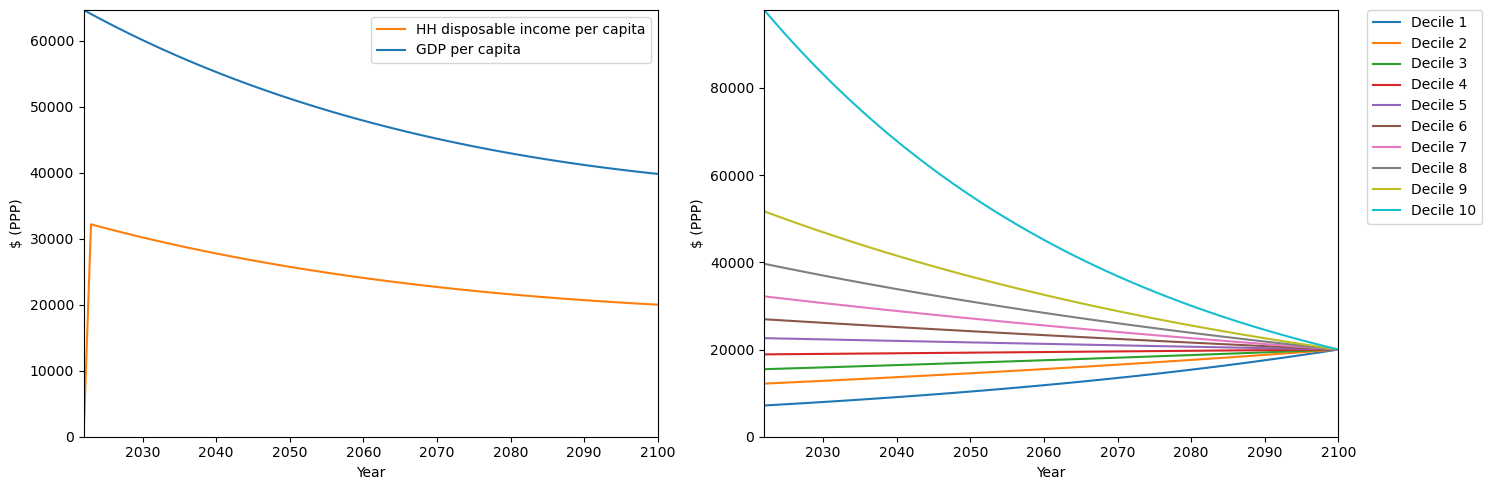

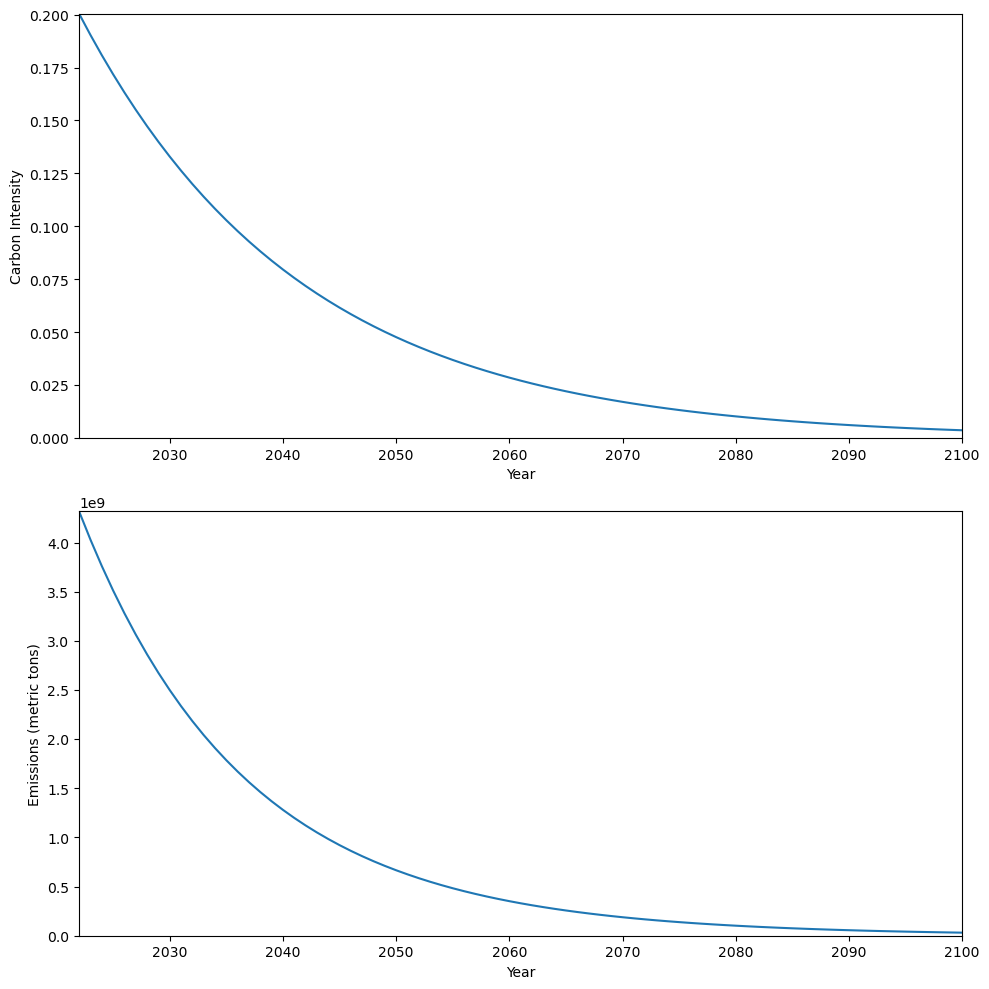

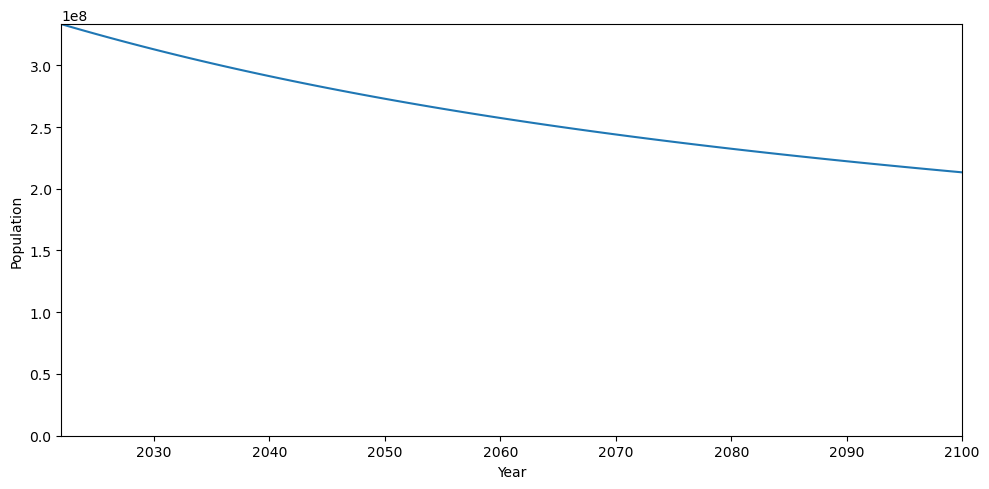

In [7]:
test_country = "United States" # this is the country name as it appears in the scenario_1.countries dictionary
plotting_1.plot_country_economy(test_country)
plotting_1.plot_country_emissions(test_country)
plotting_1.plot_country_population(test_country)


## China

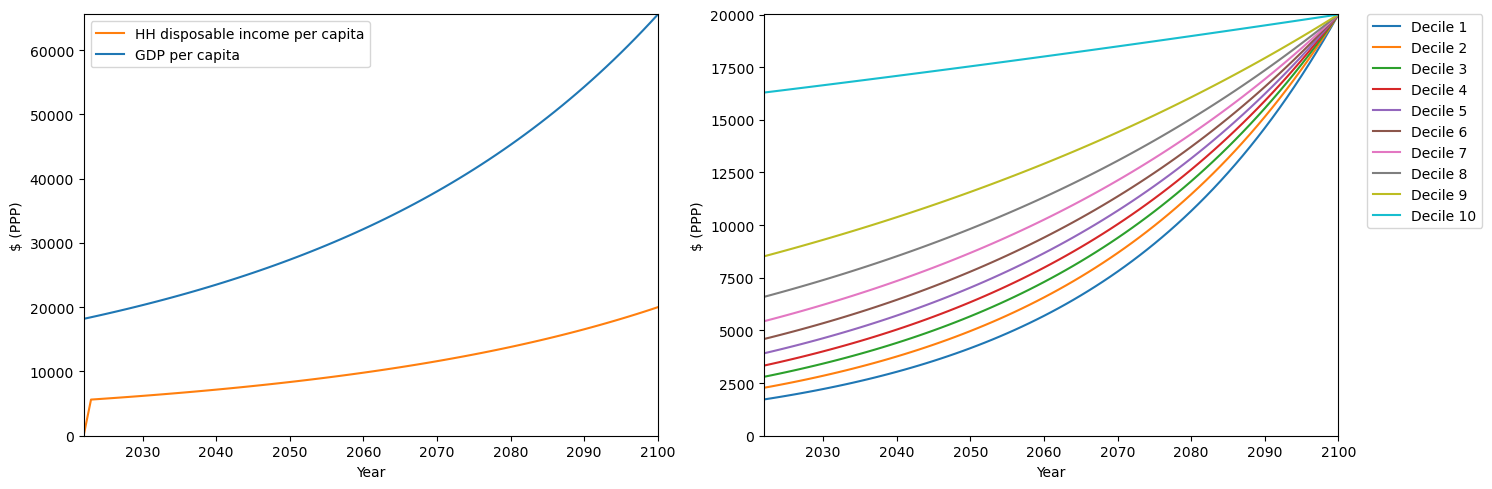

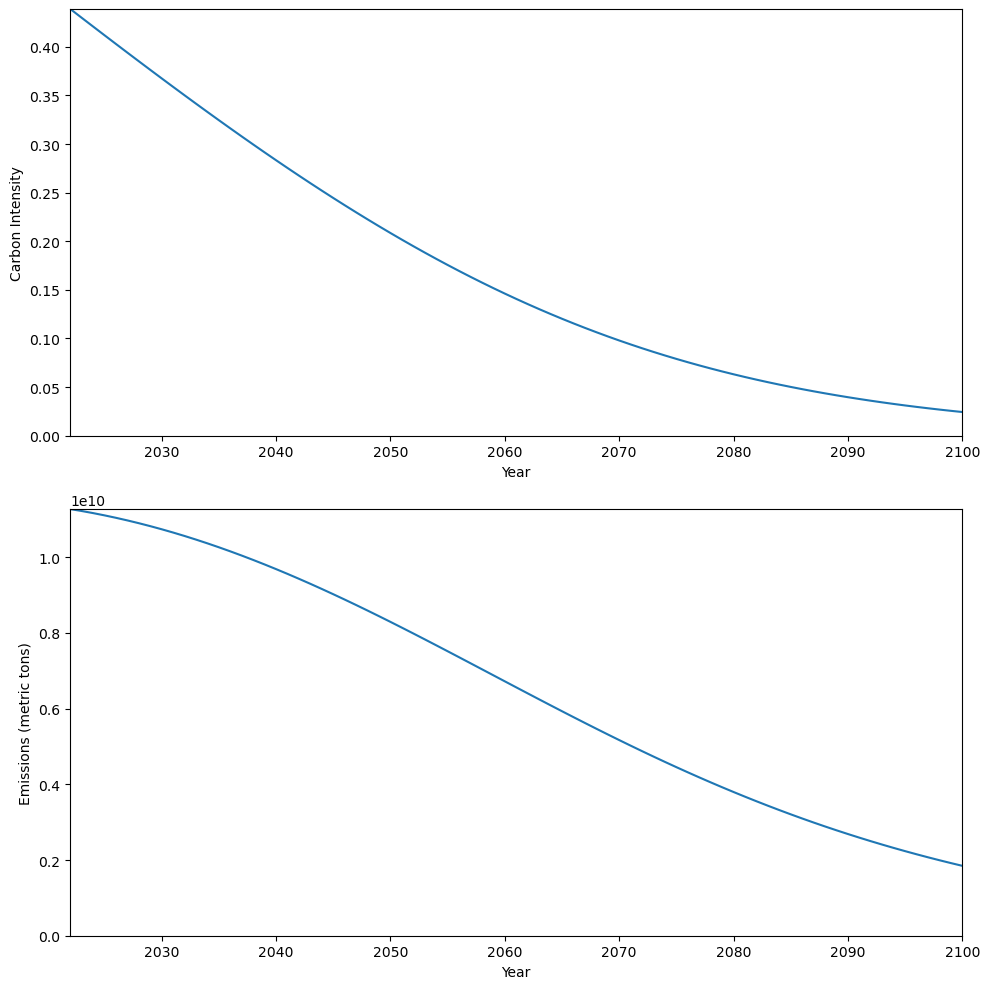

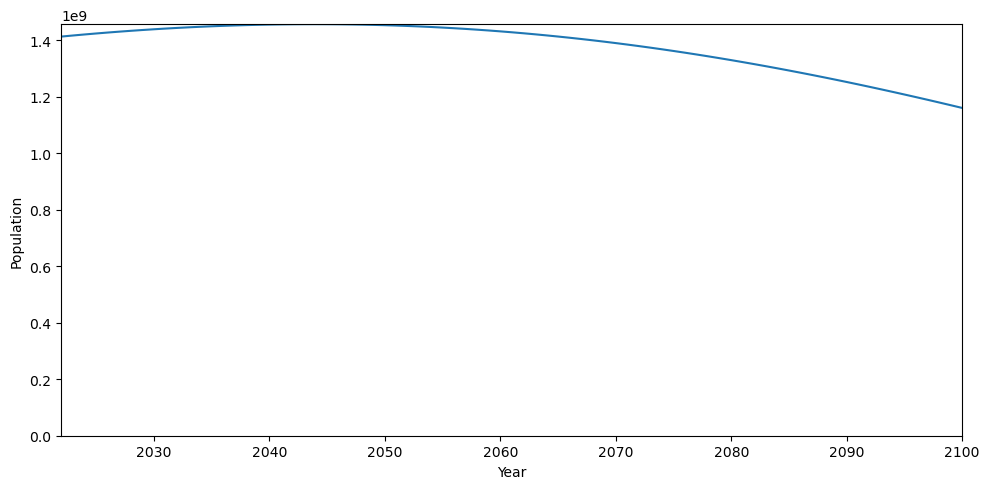

In [8]:
test_country2 = "China" # this is the country name as it appears in the scenario_1.countries dictionary
plotting_1.plot_country_economy(test_country2)
plotting_1.plot_country_emissions(test_country2)
plotting_1.plot_country_population(test_country2)


## India

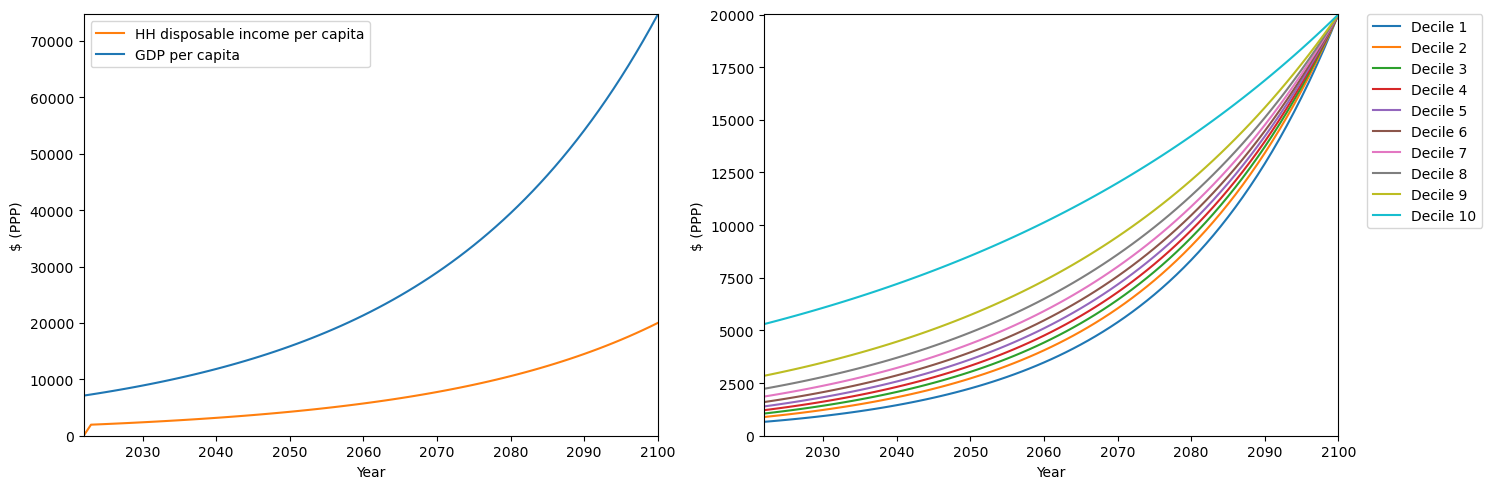

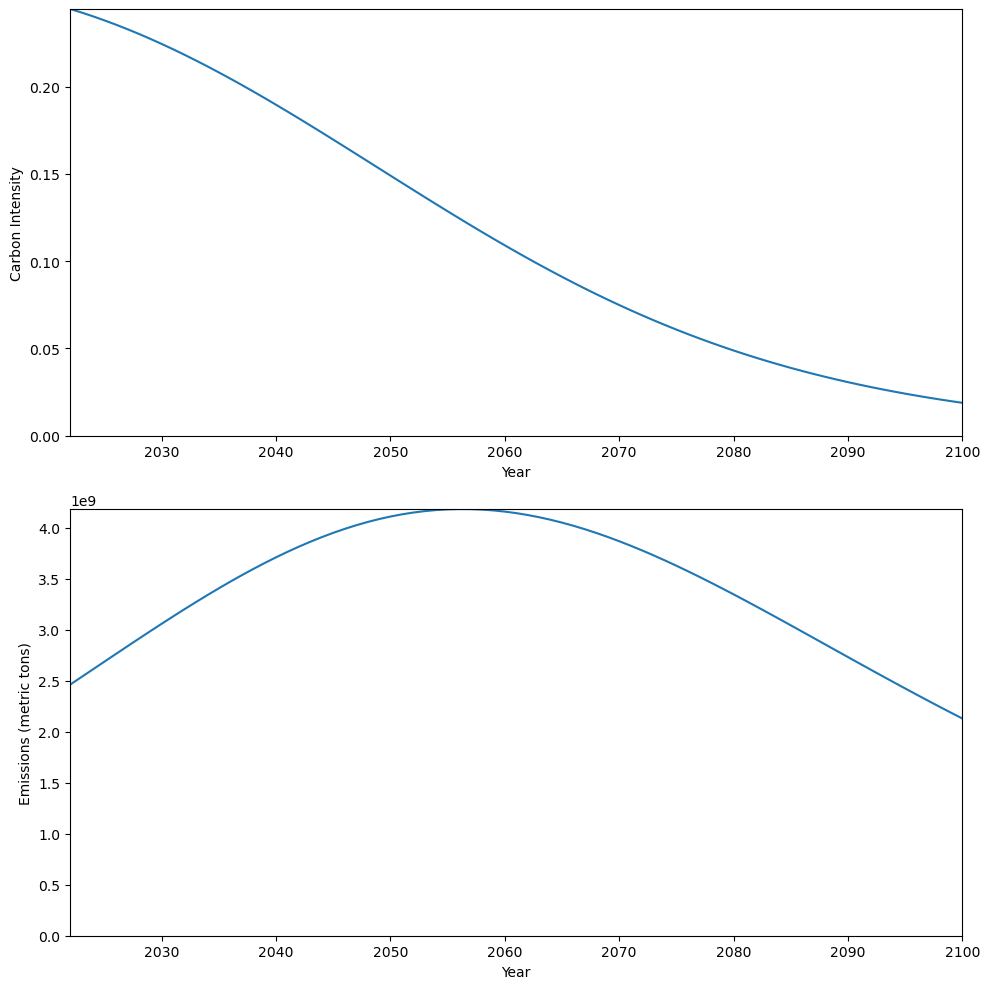

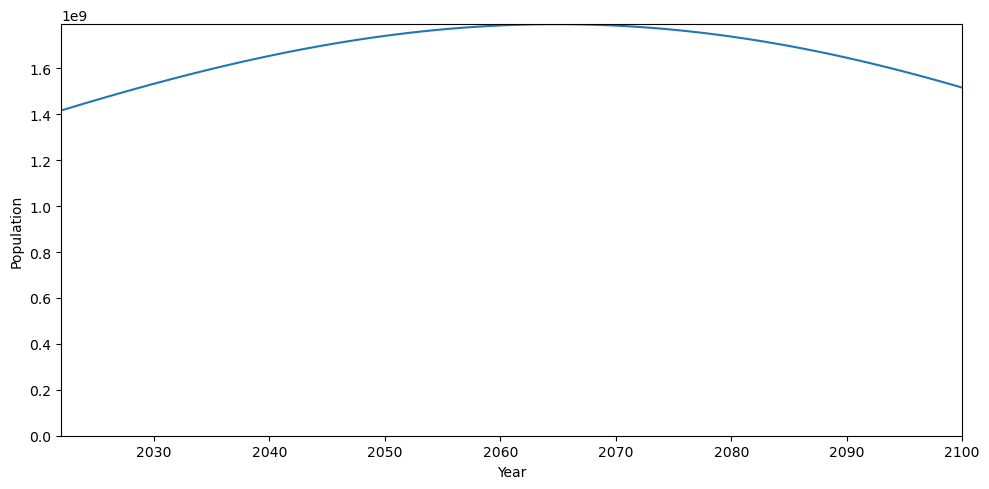

In [9]:
test_country3 = "India" # this is the country name as it appears in the scenario_1.countries dictionary
plotting_1.plot_country_economy(test_country3)
plotting_1.plot_country_emissions(test_country3)
plotting_1.plot_country_population(test_country3)


### Plot country specific and decile specific emissions trajectories.

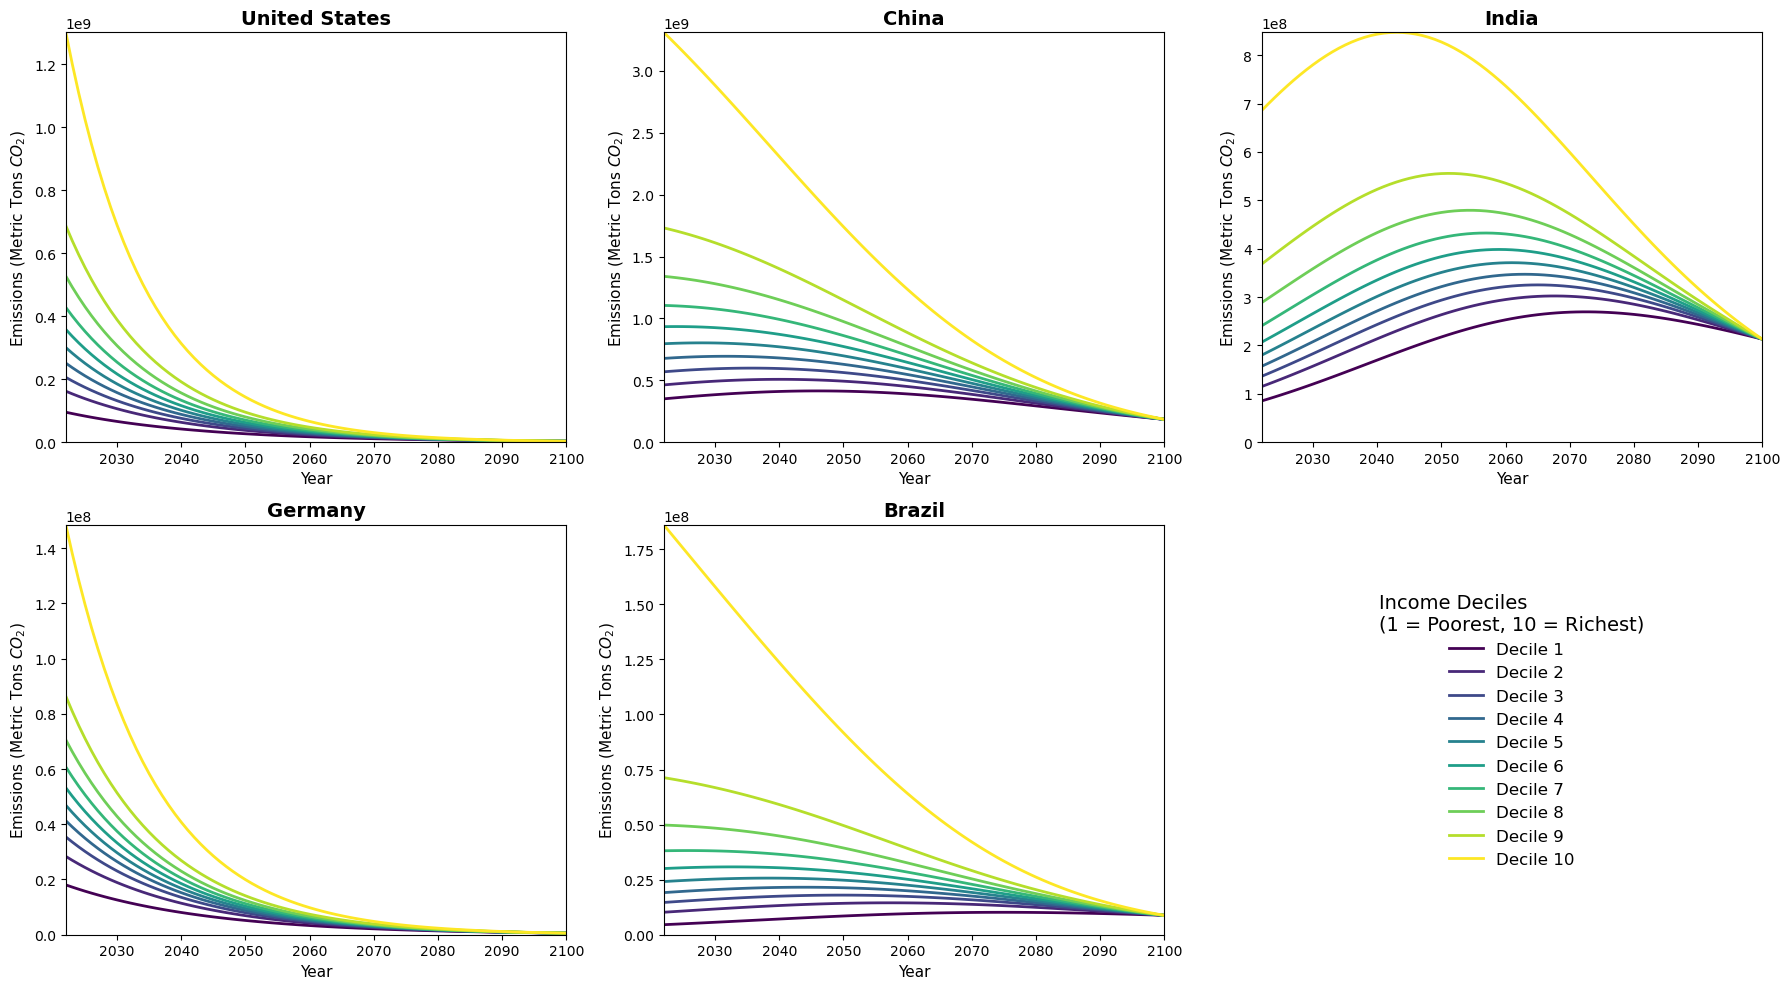

In [10]:
import matplotlib.pyplot as plt

# 1. Define the countries (Ensure these strings match the keys in scenario_1.countries)
# Note: If your keys use ISO codes instead of names, change these to ["USA", "CHN", "IND", "DEU", "BRA"]
example_countries = ["United States", "China", "India", "Germany", "Brazil"]

# 2. Create a figure with a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# 3. Loop through countries and plot them onto specific axes
for i, country in enumerate(example_countries):
    # Pass the specific subplot axis to your method
    plotting_1.plot_country_decile_emissions(country, ax=axes[i])

# 4. Turn the 6th (empty) subplot into a nice, centered master legend
axes[5].axis('off') # Hide the gridlines for the empty panel
handles, labels = axes[0].get_legend_handles_labels() # Extract legend info from the first plot
axes[5].legend(handles, labels, loc='center', frameon=False, 
               title="Income Deciles\n(1 = Poorest, 10 = Richest)", 
               fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig("decile_emissions_grid.png", dpi=300)
plt.show()

In [11]:
# run a scenario print country specific carbon budgets
#scenario_params = {"end_year": 2060,
             #      "income_goal": 10000, # in terms of 2017 USD PPP disposable household income per capita (the delineation between income and cons. exp is not necessarily clear)
              #     "carbon_budget": 1100, # in terms of GtCO2 that is gigatons of CO2        
              #     "hysteresis_tech_progress": 0.01, # this is a growth rate, so between 0 and 1, which only applies if tech_hysteresis_assumption is on
              #     "gdp_assumption": "constant_ratio", # this is a string and either (1) constant_ratio or (2) model_ratio for details see the scenario_class.py file         
              #     "pop_growth_assumption": "semi_log_model", # this is a string and either (1) UN_medium, (2) semi_log_model (3) semi_log_model_elasticity for details see the scenario_class.py file  
              #     "tech_evolution_assumption": "plausible", # this is a string and either (1) plausible or (2) necessary for details see the scenario_class.py file
              #     "tech_hysteresis_assumption": "off", # this is a string and either (1) on or (2) off for details see the scenario_class.py file 
              #     "steady_state_high_income_assumption": "off", # this is a string and either (1) on or (2) off or (3) on_with_growth for details see the scenario_class.py file
              #     "k": 0.05,
              #     "t0": 2060,
              #     "final_improvement_rate": -0.05
            
           # }

#scenario_1 = Scenario(scenario_params)
#test = scenario_1.raw_data
#scenario_1.compute_country_scenario_params()
#print(scenario_1.compute_average_global_growth_rate())
#scenario_1.run()

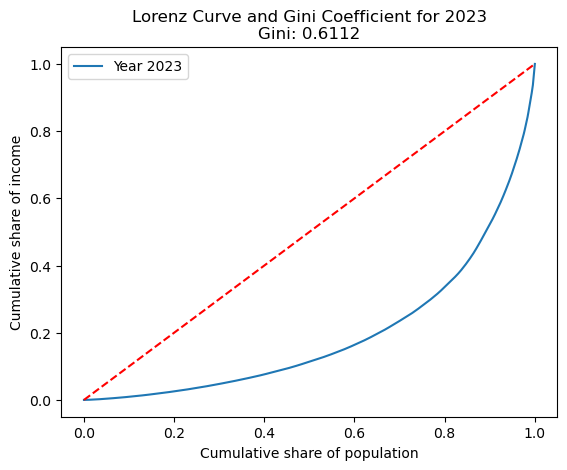

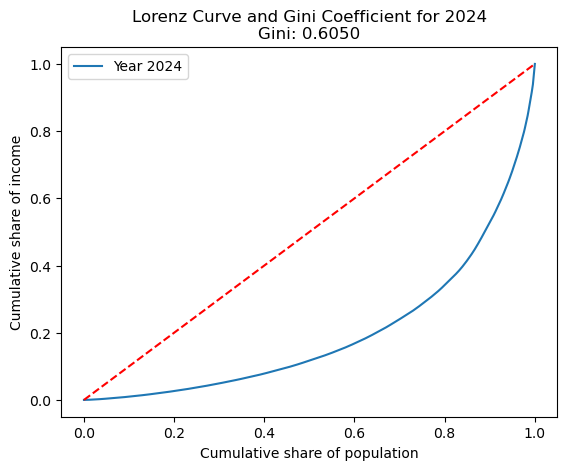

In [12]:
## check whether global population and income vector for gini coefficient and lorenz curve are proper 
# save scenario_1.gini_data dictionary to a csv file
gini_data = pd.DataFrame(scenario_1.gini_data)
gini_data.to_csv(".\gini_data.csv")
# read out the columns population and income from gini data and plot each values as lorenz curve
#subset for every year in gini_data years column the value in population and income column
# loop ovre the years
for year in gini_data["years"]:
    # Get the population data for the year
    population_data = list(gini_data.loc[gini_data["years"] == year, "population"].iloc[0])
    # Get the income data for the year
    income_data = list(gini_data.loc[gini_data["years"] == year, "income"].iloc[0])

    # compute the total income_data as well by multiplying the income_data with the population_data
    total_income = [population_data[i]*income_data[i] for i in range(len(population_data))]

    # compute the cumulative total income share and the cumulative population share
    cumulative_income_share = [sum(total_income[:i])/sum(total_income) for i in range(len(total_income)+1)]

    cumulative_population_share = [sum(population_data[:i])/sum(population_data) for i in range(len(population_data)+1)]

    # Compute the Gini coefficient
    # The area under the Lorenz curve can be computed as the sum of the areas of the trapezoids under it
    area_under_lorenz_curve = sum((cumulative_population_share[i+1] - cumulative_population_share[i]) * 
                                  (cumulative_income_share[i+1] + cumulative_income_share[i]) / 2 
                                  for i in range(len(cumulative_population_share)-1))
    gini_coefficient = 1 - 2 * area_under_lorenz_curve

    # Plot the Lorenz curve
    plt.plot(cumulative_population_share, cumulative_income_share, label=f'Year {year}')
    plt.plot([0, 1], [0, 1], 'r--')  # Line of perfect equality
    plt.xlabel('Cumulative share of population')
    plt.ylabel('Cumulative share of income')
    plt.title(f'Lorenz Curve and Gini Coefficient for {year}\nGini: {gini_coefficient:.4f}')
    plt.legend()
    plt.show()

    if year == 2024:
        break
 

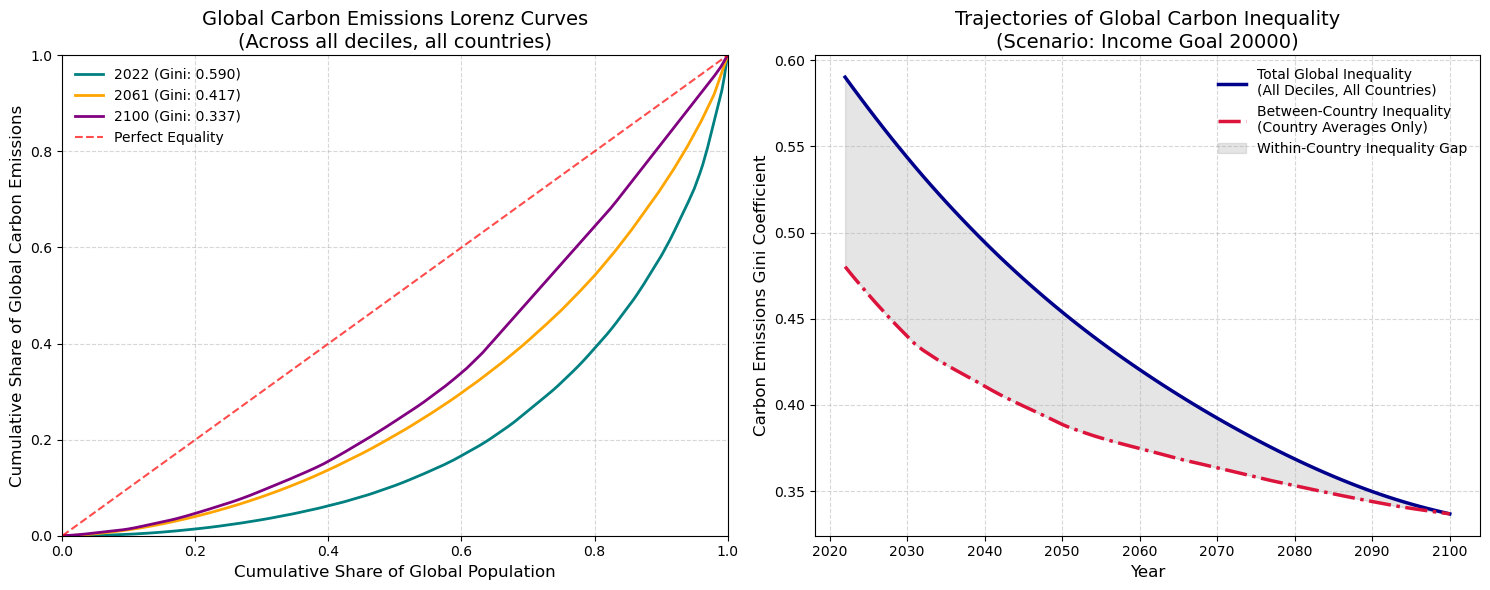

Data saved to carbon_emissions_gini_data.csv


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# POST-SIMULATION ANALYSIS: Global Carbon Inequality (Lorenz & Gini)
# ==============================================================================

# Helper function to extract emissions distributions
def get_emissions_distribution(scenario, year):
    pop_all = []
    emi_all = []
    pop_between = []
    emi_between = []
    
    assumption = getattr(scenario, 'emission_elasticity_assumption', 'off')
    
    for country in scenario.countries.values():
        c_pop = country.population_trajectory[year]
        c_gdp_pc = country.gdppc_trajectory.get(year, country.gdp_pc)
        c_macro_gdp = c_gdp_pc * c_pop
        c_mean_income = country.income_hh_trajectory.get(year, country.hh_mean)
        c_mean_income = c_mean_income if c_mean_income > 0 else 1.0
        c_macro_ci = country.carbon_intensity_trajectory.get(year, country.carbon_intensity)
        
        base_A = getattr(country, 'base_A', None)
        base_ci = getattr(country, 'base_carbon_intensity', None)
        
        country_emi = 0
        
        # Determine elasticity
        if assumption == "constant":
            eps = getattr(scenario, 'base_elasticity', 1.0)
        elif assumption == "income_dependent":
            e_min = getattr(scenario, 'elasticity_min', 0.5)
            e_max = getattr(scenario, 'elasticity_max', 1.5)
            eps = max(e_min, min(e_max, e_max - 0.2 * np.log10(max(1, c_gdp_pc / 1000))))
        else:
            eps = 1.0
            
        current_A = base_A * (c_macro_ci / base_ci) if (base_A and base_ci) else c_macro_ci
        
        for d in range(1, 11):
            yd = country.decile_trajectories[f'decile{d}'].get(year, 0)
            
            if assumption == "off":
                gdp_d = c_macro_gdp * (yd / (10 * c_mean_income))
                emi_d = (c_macro_ci * gdp_d) / 1000
            else:
                ratio = yd / c_mean_income
                ci_d = current_A * (ratio ** (eps - 1)) if ratio > 0 else 0
                gdp_d = c_macro_gdp * (yd / (10 * c_mean_income))
                emi_d = (ci_d * gdp_d) / 1000
            
            decile_pop = c_pop / 10.0
            
            # Ensure no zeroes for per-capita calculations later
            if decile_pop > 0:
                pop_all.append(decile_pop)
                emi_all.append(emi_d)
            country_emi += emi_d
            
        if c_pop > 0:
            pop_between.append(c_pop)
            emi_between.append(country_emi)
        
    return np.array(pop_all), np.array(emi_all), np.array(pop_between), np.array(emi_between)

# Helper function to compute Lorenz curve coordinates and Gini coefficient
def calc_lorenz_and_gini(pops, emissions):

    # --- NEW CHECK: Handle negative emissions ---
    if np.any(emissions < 0):
        print("Warning: Negative emissions detected. Cannot compute standard Gini coefficient.")
        # Return np.nan for Gini and dummy arrays to prevent plotting/unpacking errors downstream
        return np.nan, np.array([0.0, 1.0]), np.array([0.0, 1.0])
    

    # --- CHECK 2: Handle functional zero emissions ---
    # If total global emissions are effectively zero (adjust 1e-9 based on your units!)
    #if np.sum(emissions) < 1e-3:
        # Return perfect equality (Gini = 0)
     #   return 0.0, np.array([0.0, 1.0]), np.array([0.0, 1.0])
    # ------------------------------------------
    
    
    # Calculate per capita emissions for proper sorting
    emissions_pc = emissions / pops
    
    # Sort data by emissions per capita
    sorted_indices = np.argsort(emissions_pc)
    pops_sorted = pops[sorted_indices]
    emissions_sorted = emissions[sorted_indices]
    
    # Cumulative shares
    cum_pop = np.cumsum(pops_sorted) / np.sum(pops_sorted)
    cum_emi = np.cumsum(emissions_sorted) / np.sum(emissions_sorted)
    
    # Insert (0,0) at the beginning of the curve
    cum_pop = np.insert(cum_pop, 0, 0.0)
    cum_emi = np.insert(cum_emi, 0, 0.0)
    
    # Area under Lorenz curve using the trapezoidal rule
    auc = np.trapezoid(y=cum_emi, x=cum_pop)
    gini = 1.0 - 2.0 * auc
    
    return gini, cum_pop, cum_emi

# 1. Setup Simulation Timeline
sample_country = list(scenario_1.countries.values())[0]
simulated_years = sorted(list(sample_country.gdppc_trajectory.keys()))

start_year = simulated_years[0]
end_year = simulated_years[-1]
mid_year = simulated_years[len(simulated_years) // 2]
target_years = [start_year, mid_year, end_year]

# 2. Run over all years to collect data
gini_all_series = []
gini_between_series = []
lorenz_curves_all = {}

for year in simulated_years:
    pop_all, emi_all, pop_between, emi_between = get_emissions_distribution(scenario_1, year)
    
    # Calculate Total Gini (All Deciles)
    gini_all, cum_pop_all, cum_emi_all = calc_lorenz_and_gini(pop_all, emi_all)
    gini_all_series.append(gini_all)
    
    # Calculate Between-Country Gini (Country Averages)
    gini_between, _, _ = calc_lorenz_and_gini(pop_between, emi_between)
    gini_between_series.append(gini_between)
    
    # Save Lorenz curve data for target years
    if year in target_years:
        lorenz_curves_all[year] = (cum_pop_all, cum_emi_all, gini_all)


# ==============================================================================
# PLOTTING
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: Lorenz Curves (All Deciles) for Target Years ---
colors = ['teal', 'orange', 'purple']
for i, year in enumerate(target_years):
    cum_pop, cum_emi, gini = lorenz_curves_all[year]
    ax1.plot(cum_pop, cum_emi, label=f'{year} (Gini: {gini:.3f})', color=colors[i], lw=2)

ax1.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect Equality', alpha=0.7)
ax1.set_xlabel('Cumulative Share of Global Population', fontsize=12)
ax1.set_ylabel('Cumulative Share of Global Carbon Emissions', fontsize=12)
ax1.set_title('Global Carbon Emissions Lorenz Curves\n(Across all deciles, all countries)', fontsize=14)
ax1.legend(loc='upper left', frameon=False)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# --- PLOT 2: Time Series of Gini Coefficients ---
ax2.plot(simulated_years, gini_all_series, label='Total Global Inequality\n(All Deciles, All Countries)', color='darkblue', lw=2.5)
ax2.plot(simulated_years, gini_between_series, label='Between-Country Inequality\n(Country Averages Only)', color='crimson', lw=2.5, linestyle='-.')

# Fill the gap to represent "Within-Country Inequality" visually
ax2.fill_between(simulated_years, gini_between_series, gini_all_series, color='gray', alpha=0.2, label='Within-Country Inequality Gap')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Carbon Emissions Gini Coefficient', fontsize=12)
ax2.set_title('Trajectories of Global Carbon Inequality\n(Scenario: Income Goal ' + str(scenario_1.income_goal) + ')', fontsize=14)
ax2.legend(loc='upper right', frameon=False)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("global_carbon_gini_trajectories.png", dpi=300)
plt.show()

# ==============================================================================
# EXPORT DATA
# ==============================================================================
gini_emissions_df = pd.DataFrame({
    'Year': simulated_years,
    'Total_Global_Gini': gini_all_series,
    'Between_Country_Gini': gini_between_series,
    'Within_Country_Gap': np.array(gini_all_series) - np.array(gini_between_series)
})
gini_emissions_df.to_csv("carbon_emissions_gini_data.csv", index=False)
print("Data saved to carbon_emissions_gini_data.csv")

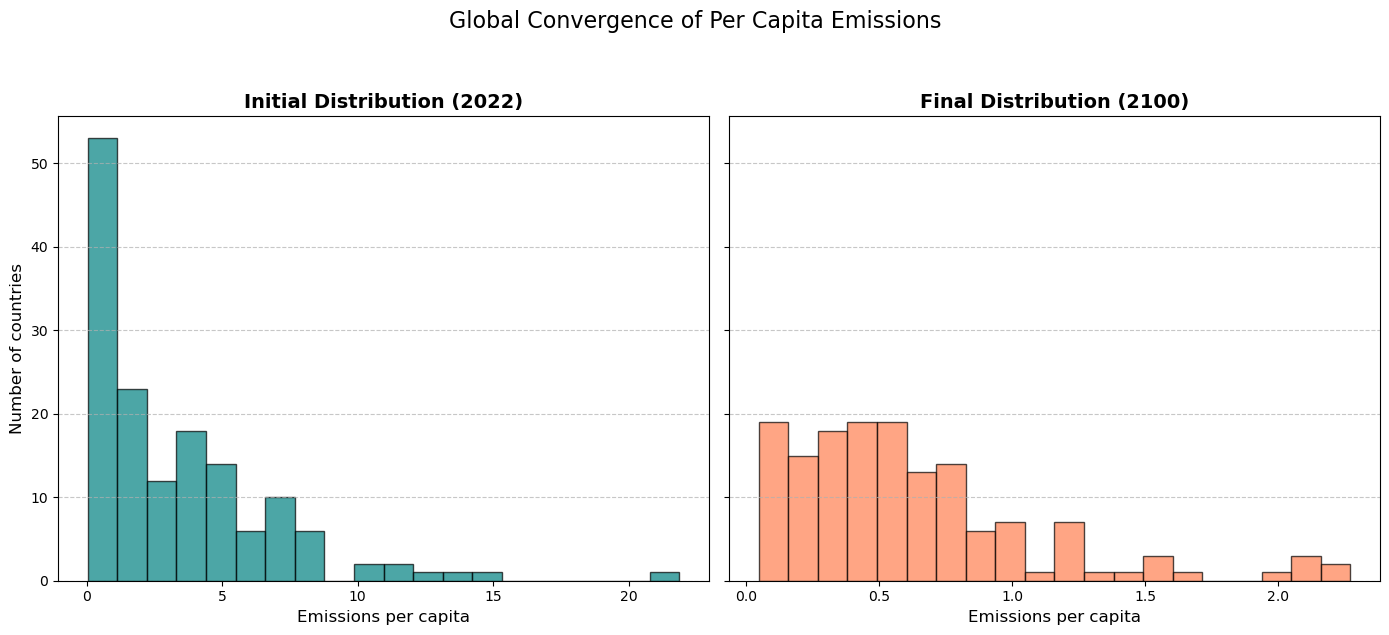

In [14]:
# Extract all the emissions per capita in countries at the beginning and end of the simulation
beginning_distribution_values = []
end_distribution_values = []
for country in scenario_1.countries.values():
    beginning_distribution_values.append(country.carbon_emissions_pc_trajectory[2022])
    end_distribution_values.append(country.carbon_emissions_pc_trajectory[2100])

# Create two side-by-side panels with a shared y-axis for accurate comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- PANEL 1: Beginning Distribution (2022) ---
ax1.hist(beginning_distribution_values, bins=20, color='teal', edgecolor='black', alpha=0.7)
ax1.set_title('Initial Distribution (2022)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Emissions per capita', fontsize=12)
ax1.set_ylabel('Number of countries', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- PANEL 2: End Distribution ---
ax2.hist(end_distribution_values, bins=20, color='coral', edgecolor='black', alpha=0.7)
ax2.set_title(f'Final Distribution ({scenario_1.end_year})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Emissions per capita', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Overall Figure Polish
fig.suptitle('Global Convergence of Per Capita Emissions', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Emissions per capita in tonnes')

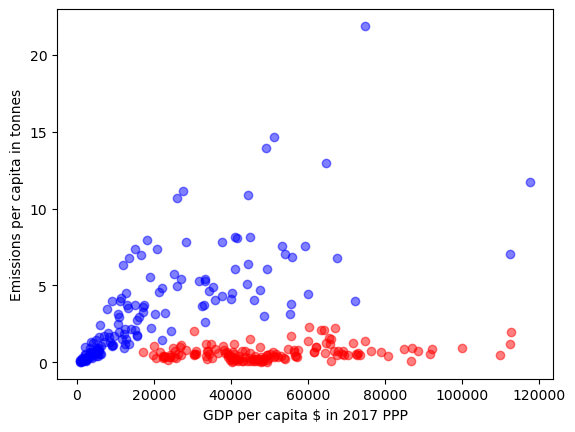

In [15]:
# also plot beginning and end scatter of emissions per capita vs. gdp per capita
fig, ax = plt.subplots()
for country in scenario_1.countries.values():
    ax.scatter(country.gdppc_trajectory[2022], country.carbon_emissions_pc_trajectory[2022], color = 'blue', alpha=0.5)
    ax.scatter(country.gdppc_trajectory[scenario_1.end_year], country.carbon_emissions_pc_trajectory[scenario_1.end_year], color = 'red', alpha=0.5)
    
# name x axis
ax.set_xlabel('GDP per capita $ in 2017 PPP')
# name y axis
ax.set_ylabel('Emissions per capita in tonnes')
# fit a linear fit to the two different data sets directly in the scatter plot
# first do it for the beginning

# Analyze national gini coefficients

In [16]:
print(scenario_1.countries['United States'].decile_trajectories)

{'decile1': {2022: 7167.118748879033, 2023: 7262.037972931036, 2024: 7358.214279418857, 2025: 7455.66431677453, 2026: 7554.404953917054, 2027: 7654.4532831724555, 2028: 7755.826623232528, 2029: 7858.542522152751, 2030: 7962.61876038992, 2031: 8068.073353879995, 2032: 8174.924557156724, 2033: 8283.19086651156, 2034: 8392.891023195429, 2035: 8504.044016662898, 2036: 8616.669087859322, 2037: 8730.785732551501, 2038: 8846.413704702472, 2039: 8963.573019890977, 2040: 9082.283958776228, 2041: 9202.567070608557, 2042: 9324.443176786552, 2043: 9447.933374461314, 2044: 9573.059040188446, 2045: 9699.841833628392, 2046: 9828.30370129581, 2047: 9958.466880358574, 2048: 10090.353902487102, 2049: 10223.98759775467, 2050: 10359.391098589362, 2051: 10496.58784377837, 2052: 10635.601582525333, 2053: 10776.45637856139, 2054: 10919.176614310698, 2055: 11063.786995111106, 2056: 11210.312553490732, 2057: 11358.778653501171, 2058: 11509.210995108098, 2059: 11661.635618640017, 2060: 11816.078909295922, 2061:

In [17]:
# create an empty dataframe in pandas with five columns country, decile, year, scenario, consumption_exp
scenario_full_data = pd.DataFrame(columns=['scenario', 'country', 'decile', 'year', 'consumption_exp'])
scenario_gini_data = pd.DataFrame(columns=['scenario', 'country', 'year', 'gini'])


# make function to add n-element list to dataframe

def add_list_to_dataframe(df, elements):
    # Validate the input
    #print(len(elements))
    #print(len(df.columns))
    if len(elements) != len(df.columns):
        raise ValueError("The number of elements must be exactly equal to the number of columns.")
    
    # Create a DataFrame from the list and append it to the existing DataFrame
    new_df = pd.DataFrame([elements], columns=df.columns)
    df = pd.concat([df, new_df], ignore_index=True)
    
    return df

In [18]:
# loop over the countries and add each country with the concat() method to the dataframe
i = 0
scenario_id = str(scenario_1.income_goal) + '_' + str(scenario_1.end_year)
for country in scenario_1.countries.values():
    i += 1
    for decile, years in country.decile_trajectories.items():
        for year, value in years.items():
            countryvalues = [] # create empty list for current country values
            countryvalues.append(scenario_id) # add scenario_id to the list
            countryvalues.append(country.code) # add country code to the list
            countryvalues.append(decile)
            #print(year)
            countryvalues.append(year)
            #print(value)
            countryvalues.append(value)
            scenario_full_data = add_list_to_dataframe(scenario_full_data, countryvalues)
    if i == 2:
         break





C:\Users\yoswald\AppData\Local\Temp\ipykernel_11796\3909973554.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df], ignore_index=True)


In [19]:
# loop over the countries and add each country with the concat() method to the dataframe
i = 0
scenario_id = str(scenario_1.income_goal) + '_' + str(scenario_1.end_year)
for country in scenario_1.countries.values():
    i += 1
    for value, years in country.gini_coefficient_trajectory.items():
            countryvalues2 = [] # create empty list for current country values
            countryvalues2.append(scenario_id) # add scenario_id to the list
            countryvalues2.append(country.code) # add country code to the list
            countryvalues2.append(years)
            countryvalues2.append(value)   
            scenario_gini_data = add_list_to_dataframe(scenario_gini_data, countryvalues2)
    if i == 2:
         break


C:\Users\yoswald\AppData\Local\Temp\ipykernel_11796\3909973554.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df], ignore_index=True)


-0.003752360817267042


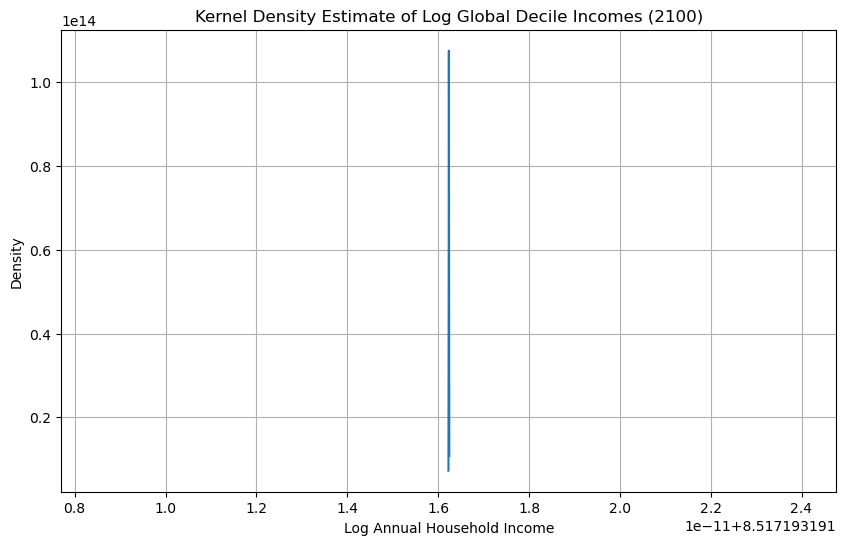

In [20]:
scenario_params = {"end_year": 2100, # end year of convergence not for the whole trajectory which is now always 2100
                   "income_goal": 5000, # in terms of 2017 USD PPP disposable household income per capita (the delineation between income and cons. exp is not necessarily clear)
                   "carbon_budget": 1150*0.95 - 2*35, # in terms of GtCO2 that is gigatons of CO2   and times 95% because 95% population coverage     
                   #"hysteresis_tech_progress": 0.01, # this is a growth rate, so between 0 and 1, which only applies if tech_hysteresis_assumption is on
                   "gdp_assumption": "constant_ratio", # this is a string and either (1) constant_ratio or (2) model_ratio for details see the scenario_class.py file         
                   "pop_growth_assumption": "semi_log_model", # this is a string and either (1) UN_medium, (2) semi_log_model (3) semi_log_model_elasticity for details see the scenario_class.py file  
                   "tech_evolution_assumption": "plausible", # this is a string and either (1) plausible or (2) necessary for details see the scenario_class.py file
                   "tech_hysteresis_assumption": "pessimistic_degrowth", # this is a string and either (1) optimistic_degrowth or (2) pessimistic_degrowth or (3) off for details see the scenario_class.py file 
                   "steady_state_high_income_assumption": "off", # this is a string and either (1) on or (2) off or (3) on_with_growth for details see the scenario_class.py file
                   "k": 0.05,
                   "t0": 2060,
                   "final_improvement_rate": -0.05,
                   "population_hysteresis_assumption": "off", # this is a string and either (1) on or (2) off for details see the scenario_class.py file      
                   "run_until_2100": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_assumption": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_level_2100": 5, #  in gigatons of CO2 per year, so 0.95 means 950 million tons of CO2 per year
                     # --- ADD THESE NEW PARAMETERS HERE ---
                   "elasticity_assumption": "off", # Options: "off", "constant", "income_dependent"
                   "elasticity_value": 1.2                                # Only used if assumption is "constant"
            
            }


scenario_1 = Scenario(scenario_params)
#test = scenario_1.raw_data
scenario_1.compute_country_scenario_params()
print(scenario_1.compute_average_global_growth_rate())
#scenario_1.run()

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Ensure you have a Scenario instance that's been run through to 2100:
# scenario = Scenario(scenario_params)
scenario_1.run()

# Retrieve the decile income distribution data
incomes, weights = scenario_1.get_decile_income_distribution_data()

# Transform to log incomes
log_incomes = np.log(incomes)

# Perform weighted kernel density estimation on log incomes
kde = gaussian_kde(log_incomes, weights=weights)
xgrid = np.linspace(log_incomes.min(), log_incomes.max(), 200)
density = kde(xgrid)

# Plot the KDE of log incomes
plt.figure(figsize=(10, 6))
plt.plot(xgrid, density)
plt.xlabel("Log Annual Household Income")
plt.ylabel("Density")
plt.title("Kernel Density Estimate of Log Global Decile Incomes (2100)")
plt.grid(True)
plt.show()
plt.show()

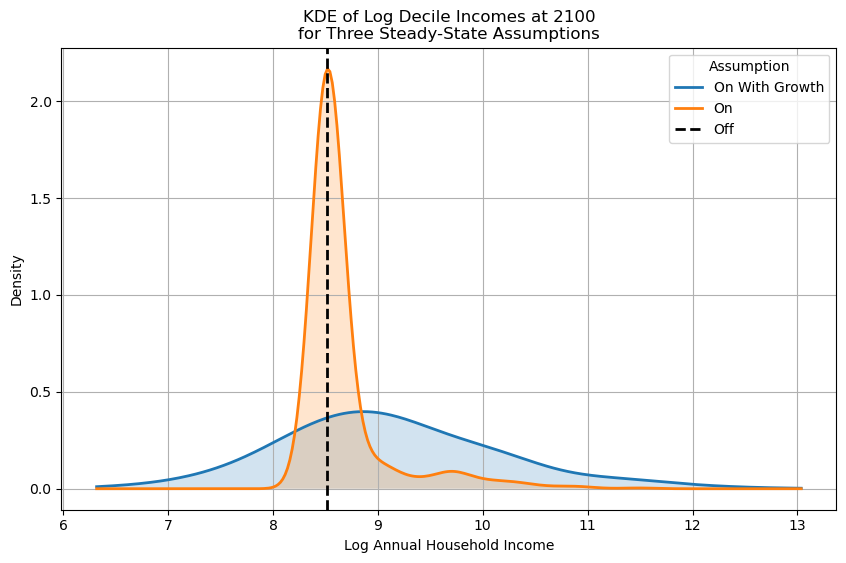

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scenario_class import Scenario

# Base scenario parameters (common to all three)
base_params = {"end_year": 2100, # end year of convergence not for the whole trajectory which is now always 2100
                   "income_goal": 5000, # in terms of 2017 USD PPP disposable household income per capita (the delineation between income and cons. exp is not necessarily clear)
                   "carbon_budget": 1150*0.95 - 2*35, # in terms of GtCO2 that is gigatons of CO2   and times 95% because 95% population coverage     
                   #"hysteresis_tech_progress": 0.01, # this is a growth rate, so between 0 and 1, which only applies if tech_hysteresis_assumption is on
                   "gdp_assumption": "constant_ratio", # this is a string and either (1) constant_ratio or (2) model_ratio for details see the scenario_class.py file         
                   "pop_growth_assumption": "semi_log_model", # this is a string and either (1) UN_medium, (2) semi_log_model (3) semi_log_model_elasticity for details see the scenario_class.py file  
                   "tech_evolution_assumption": "plausible", # this is a string and either (1) plausible or (2) necessary for details see the scenario_class.py file
                   "tech_hysteresis_assumption": "pessimistic_degrowth", # this is a string and either (1) optimistic_degrowth or (2) pessimistic_degrowth or (3) off for details see the scenario_class.py file 
                   "steady_state_high_income_assumption": "off", # this is a string and either (1) on or (2) off or (3) on_with_growth for details see the scenario_class.py file
                   "k": 0.05,
                   "t0": 2060,
                   "final_improvement_rate": -0.05,
                   "population_hysteresis_assumption": "off", # this is a string and either (1) on or (2) off for details see the scenario_class.py file      
                   "run_until_2100": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_assumption": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_level_2100": 5, #  in gigatons of CO2 per year, so 0.95 means 950 million tons of CO2 per year
                     # --- ADD THESE NEW PARAMETERS HERE ---
                   "elasticity_assumption": "off", # Options: "off", "constant", "income_dependent"
                   "elasticity_value": 1.2                                # Only used if assumption is "constant"
            
            }
assumptions = ["on_with_growth", "on", "off"]

# Collect log-incomes and weights for each assumption
data_by_assumption = {}
for assumption in assumptions:
    params = base_params.copy()
    params["steady_state_high_income_assumption"] = assumption
    scenario = Scenario(params)
    scenario.compute_country_scenario_params()
    scenario.run()
    incomes, weights = scenario.get_decile_income_distribution_data()
    log_incomes = np.log(incomes)
    data_by_assumption[assumption] = (log_incomes, weights)

# Common x-grid
all_logs = np.concatenate([vals[0] for vals in data_by_assumption.values()])
xgrid = np.linspace(all_logs.min(), all_logs.max(), 300)

# Precompute densities for non-constant cases
densities = {}
for assumption, (logs, w) in data_by_assumption.items():
    # Check if all values are equal (constant distribution)
    if not np.allclose(logs, logs[0]):
        kde = gaussian_kde(logs, weights=w)
        densities[assumption] = kde(xgrid)

# Determine max density for filling the "off" vertical line
max_density = max(d.max() for d in densities.values())

# Plot
plt.figure(figsize=(10, 6))

# Plot KDEs for 'on_with_growth' and 'on'
for assumption in ["on_with_growth", "on"]:
    density = densities[assumption]
    label = assumption.replace("_", " ").title()
    plt.plot(xgrid, density, label=label, linewidth=2)
    plt.fill_between(xgrid, density, alpha=0.2)

# Plot vertical line for 'off'
logs_off, _ = data_by_assumption["off"]
x0 = logs_off[0]
plt.axvline(x0, color='k', linestyle='--', linewidth=2, label="Off")
plt.fill_betweenx([0, max_density], x0, x0, alpha=0.2)

plt.xlabel("Log Annual Household Income")
plt.ylabel("Density")
plt.title("KDE of Log Decile Incomes at 2100\nfor Three Steady-State Assumptions")
plt.legend(title="Assumption")
plt.grid(True)
plt.show()


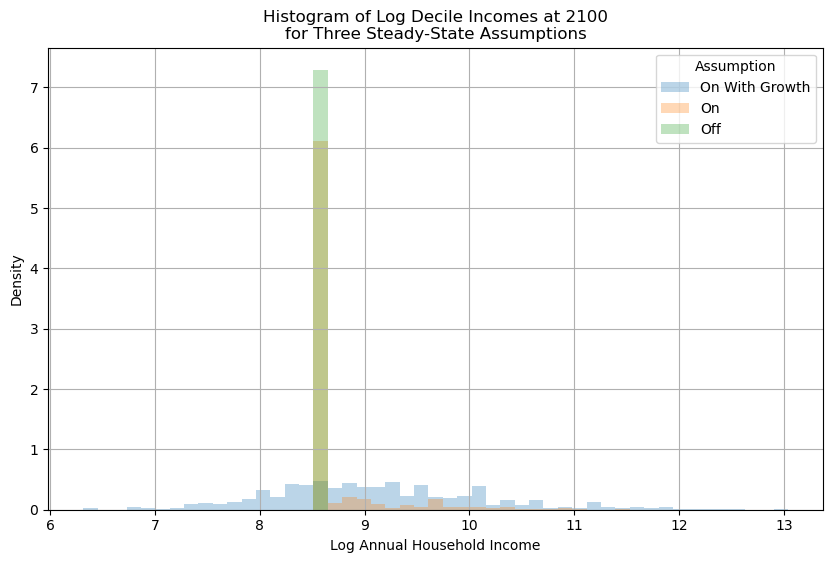

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scenario_class import Scenario

# Base scenario parameters (common to all three)
base_params = {"end_year": 2100, # end year of convergence not for the whole trajectory which is now always 2100
                   "income_goal": 5000, # in terms of 2017 USD PPP disposable household income per capita (the delineation between income and cons. exp is not necessarily clear)
                   "carbon_budget": 1150*0.95 - 2*35, # in terms of GtCO2 that is gigatons of CO2   and times 95% because 95% population coverage     
                   #"hysteresis_tech_progress": 0.01, # this is a growth rate, so between 0 and 1, which only applies if tech_hysteresis_assumption is on
                   "gdp_assumption": "constant_ratio", # this is a string and either (1) constant_ratio or (2) model_ratio for details see the scenario_class.py file         
                   "pop_growth_assumption": "semi_log_model", # this is a string and either (1) UN_medium, (2) semi_log_model (3) semi_log_model_elasticity for details see the scenario_class.py file  
                   "tech_evolution_assumption": "plausible", # this is a string and either (1) plausible or (2) necessary for details see the scenario_class.py file
                   "tech_hysteresis_assumption": "pessimistic_degrowth", # this is a string and either (1) optimistic_degrowth or (2) pessimistic_degrowth or (3) off for details see the scenario_class.py file 
                   "steady_state_high_income_assumption": "off", # this is a string and either (1) on or (2) off or (3) on_with_growth for details see the scenario_class.py file
                   "k": 0.05,
                   "t0": 2060,
                   "final_improvement_rate": -0.05,
                   "population_hysteresis_assumption": "off", # this is a string and either (1) on or (2) off for details see the scenario_class.py file      
                   "run_until_2100": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_assumption": "on", # this is a string and either (1) on or (2) off for details see the scenario_class.py file
                   "cdr_level_2100": 5, #  in gigatons of CO2 per year, so 0.95 means 950 million tons of CO2 per year
                     # --- ADD THESE NEW PARAMETERS HERE ---
                   "elasticity_assumption": "off", # Options: "off", "constant", "income_dependent"
                   "elasticity_value": 1.2                                # Only used if assumption is "constant"
            
            }
assumptions = ["on_with_growth", "on", "off"]
hist_data = {}

# Run each scenario and collect log‐incomes + weights
for assumption in assumptions:
    params = base_params.copy()
    params["steady_state_high_income_assumption"] = assumption

    scenario = Scenario(params)
    scenario.compute_country_scenario_params()
    scenario.run()

    incomes, weights = scenario.get_decile_income_distribution_data()
    hist_data[assumption] = (np.log(incomes), weights)

# Choose common bins over the full range
all_logs = np.concatenate([logs for logs, w in hist_data.values()])
bins = np.linspace(all_logs.min(), all_logs.max(), 50)

# Plot
plt.figure(figsize=(10, 6))
for assumption, (logs, w) in hist_data.items():
    label = assumption.replace("_", " ").title()
    # for the "off" case (all identical), this will collapse to a single-bin spike
    plt.hist(
        logs,
        bins=bins,
        weights=w,
        density=True,
        histtype='stepfilled',
        alpha=0.3,
        label=label
    )

plt.xlabel("Log Annual Household Income")
plt.ylabel("Density")
plt.title("Histogram of Log Decile Incomes at 2100\nfor Three Steady-State Assumptions")
plt.legend(title="Assumption")
plt.grid(True)
plt.show()


In [23]:
# For all countries, check that gdp_trajectory[year] == gdppc_trajectory[year] * population_trajectory[year] for all years, starting from 2023
for country in scenario_1.countries.values():
    years = [year for year in country.gdppc_trajectory.keys() if year >= 2023]
    for year in years:
        gdp = country.gdp_trajectory[year]
        gdppc = country.gdppc_trajectory[year]
        pop = country.population_trajectory[year]
        computed_gdp = gdppc * pop
        if not np.isclose(gdp, computed_gdp, rtol=1e-6):
            print(f"Mismatch in {country.code} for year {year}: gdp={gdp}, gdppc*pop={computed_gdp}")
        else:
            print(f"{country.code} {year}: seems correct")

AGO 2023: seems correct
AGO 2024: seems correct
AGO 2025: seems correct
AGO 2026: seems correct
AGO 2027: seems correct
AGO 2028: seems correct
AGO 2029: seems correct
AGO 2030: seems correct
AGO 2031: seems correct
AGO 2032: seems correct
AGO 2033: seems correct
AGO 2034: seems correct
AGO 2035: seems correct
AGO 2036: seems correct
AGO 2037: seems correct
AGO 2038: seems correct
AGO 2039: seems correct
AGO 2040: seems correct
AGO 2041: seems correct
AGO 2042: seems correct
AGO 2043: seems correct
AGO 2044: seems correct
AGO 2045: seems correct
AGO 2046: seems correct
AGO 2047: seems correct
AGO 2048: seems correct
AGO 2049: seems correct
AGO 2050: seems correct
AGO 2051: seems correct
AGO 2052: seems correct
AGO 2053: seems correct
AGO 2054: seems correct
AGO 2055: seems correct
AGO 2056: seems correct
AGO 2057: seems correct
AGO 2058: seems correct
AGO 2059: seems correct
AGO 2060: seems correct
AGO 2061: seems correct
AGO 2062: seems correct
AGO 2063: seems correct
AGO 2064: seems 

## Supplementary Figure 5

Running scenario with params: {'end_year': 2100, 'income_goal': 5000, 'carbon_budget': 1022.5, 'gdp_assumption': 'constant_ratio', 'pop_growth_assumption': 'semi_log_model', 'tech_evolution_assumption': 'plausible', 'tech_hysteresis_assumption': 'pessimistic_degrowth', 'steady_state_high_income_assumption': 'off', 'k': 0.05, 't0': 2060, 'final_improvement_rate': -0.05, 'population_hysteresis_assumption': 'off', 'run_until_2100': 'on', 'cdr_assumption': 'on', 'cdr_level_2100': 5, 'elasticity_assumption': 'off', 'elasticity_value': 1.0}
Brazil - Off (No Elasticity) - Emissions per capita distribution: [0.2115750406631771, 0.4738734303668462, 0.6803743132696638, 0.8880536644534556, 1.1209207488801347, 1.3953390521601745, 1.7702870277822436, 2.3126472922257553, 3.3122014980474876, 8.643589961906244]
China - Off (No Elasticity) - Emissions per capita distribution: [2.4800865053330896, 3.2776808555287253, 4.027534837650029, 4.7940795817892425, 5.6329335831959675, 6.60960347412283, 7.82466120

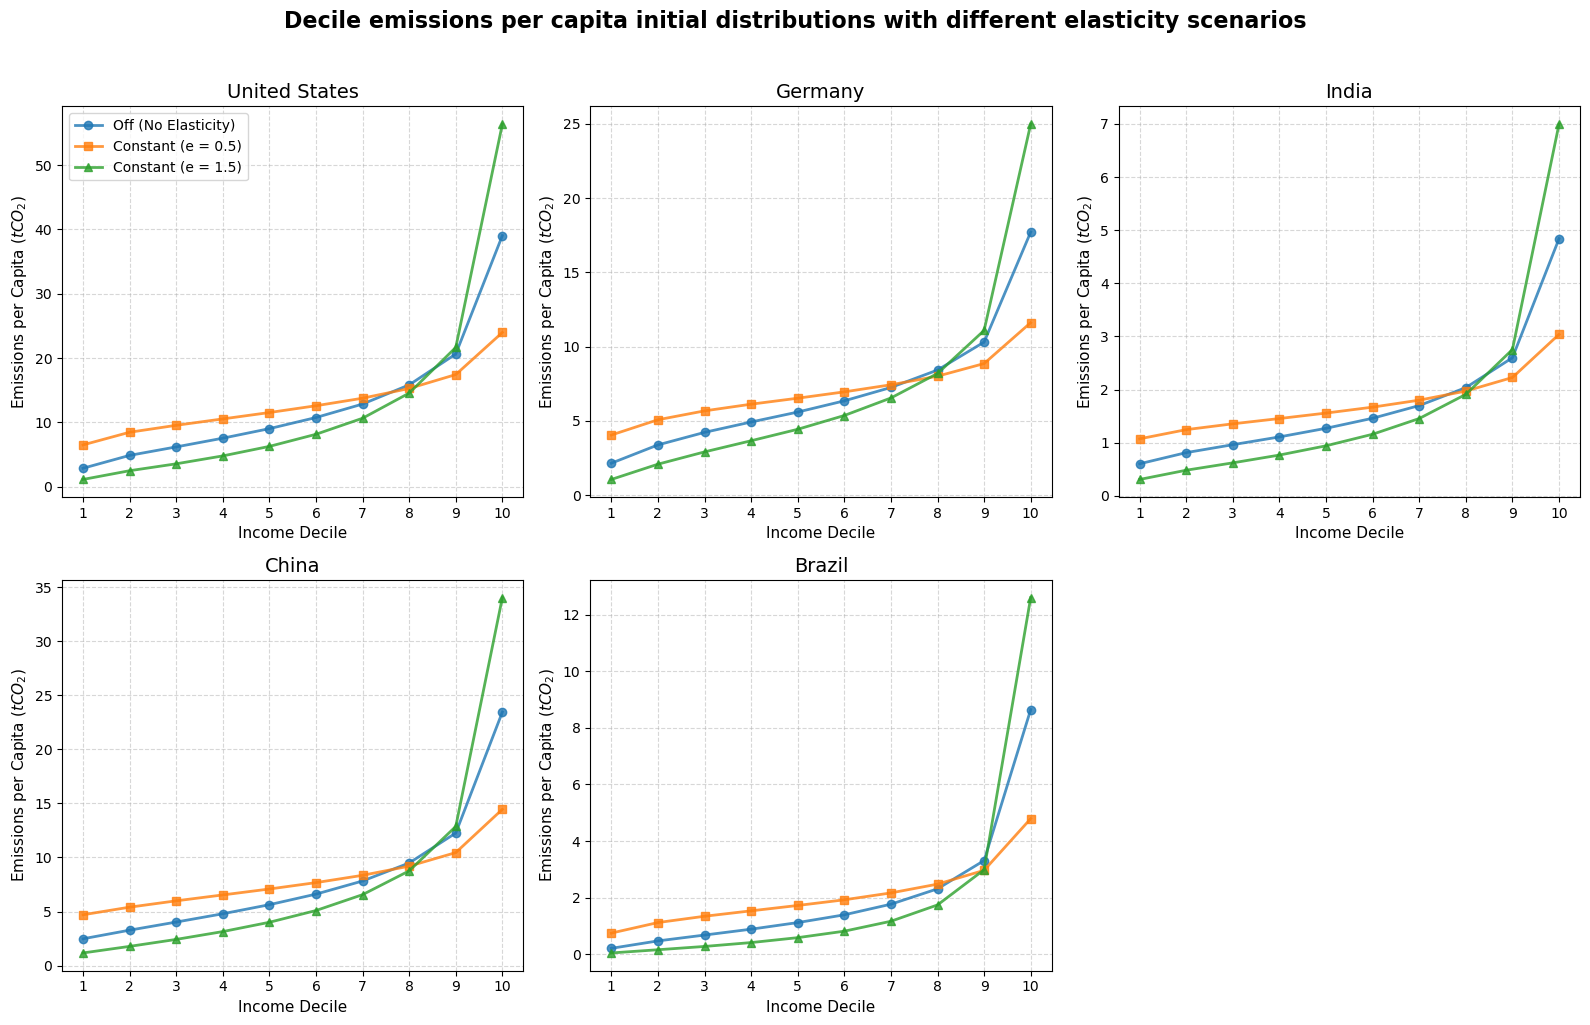

In [24]:
import sys
import os

# 1. Safely change the current working directory to the main project root.
# This ensures that when scenario_class looks for the "data" folder, it actually finds it.
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    os.chdir('..')

# 2. Add the 'model_code' folder to sys.path so Python can find your classes
module_path = os.path.abspath('model_code')
if module_path not in sys.path:
    sys.path.append(module_path)

# 3. Standard imports
import copy
import numpy as np
import matplotlib.pyplot as plt
from scenario_class import Scenario

# 1. Base scenario parameters
base_scenario_params = {
    "end_year": 2100,
    "income_goal": 5000,
    "carbon_budget": 1150 * 0.95 - 2 * 35,
    "gdp_assumption": "constant_ratio",
    "pop_growth_assumption": "semi_log_model",
    "tech_evolution_assumption": "plausible",
    "tech_hysteresis_assumption": "pessimistic_degrowth",
    "steady_state_high_income_assumption": "off",
    "k": 0.05,
    "t0": 2060,
    "final_improvement_rate": -0.05,
    "population_hysteresis_assumption": "off",
    "run_until_2100": "on",
    "cdr_assumption": "on",
    "cdr_level_2100": 5
}

# The four elasticity configurations
elasticity_configs = [
    {"label": "Off (No Elasticity)", "elasticity_assumption": "off", "elasticity_value": 1.0},
    {"label": "Constant (e = 0.5)", "elasticity_assumption": "constant", "elasticity_value": 0.5},
    {"label": "Constant (e = 1.5)", "elasticity_assumption": "constant", "elasticity_value": 1.5},
    #{"label": "Income Dependent", "elasticity_assumption": "income_dependent", "elasticity_value": None}
]

target_countries = ["United States", "Germany", "India", "China", "Brazil"]
deciles = np.arange(1, 11)
results = {country: {} for country in target_countries}

# 2. Initialize scenarios
for config in elasticity_configs:
    params = copy.deepcopy(base_scenario_params)
    params["elasticity_assumption"] = config["elasticity_assumption"]
    if config["elasticity_value"] is not None:
        params["elasticity_value"] = config["elasticity_value"]

    print(f"Running scenario with params: {params}")
    scenario = Scenario(params)
    scenario.compute_country_scenario_params()
    
    # 3. Extract the computed array directly from the robust dictionary tracking!
    for name, country in scenario.countries.items():
        if name in target_countries:
            
            # Get the population for a single decile in the base year (2022)
            pop_d = country.population_trajectory[2022] / 10
            
            # Construct the per-capita emissions directly from the recorded absolute dictionary!
            emissions_pc = []
            for d in range(1, 11):
                # Read the absolute metric tons for 2022, divide by decile population
                abs_emissions = country.decile_emissions_trajectories[f'decile{d}'][2022]
                emissions_pc.append(abs_emissions / pop_d)
                
            results[name][config['label']] = emissions_pc
            
            # print the emissions per capita distribution for the country and the current config
            print(f"{name} - {config['label']} - Emissions per capita distribution: {emissions_pc}")
            
            # assert things are not zero or all the same or negative 
            if np.all(np.array(emissions_pc) == emissions_pc[0]):
                print(f"Warning: {name} has identical emissions per capita across all deciles for config '{config['label']}'")
            if np.any(np.array(emissions_pc) < 0):
                print(f"Warning: {name} has negative emissions per capita for config '{config['label']}'")
            if np.all(np.array(emissions_pc) == 0):
                print(f"Warning: {name} has zero emissions per capita across all deciles for config '{config['label']}'")

# 4. Plotting
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

# Expanded colors and markers to handle 4 configurations
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
markers = ['o', 's', '^', 'D']

for idx, country in enumerate(target_countries):
    ax = axes[idx]
    for c_idx, config in enumerate(elasticity_configs):
        label = config["label"]
        emissions = results[country].get(label, [])
        if len(emissions) == 10:
            ax.plot(deciles, emissions, marker=markers[c_idx], color=colors[c_idx], 
                    linewidth=2, label=label, alpha=0.8)
            
    ax.set_title(country, fontsize=14)
    ax.set_xlabel('Income Decile', fontsize=11)
    ax.set_ylabel('Emissions per Capita ($tCO_2$)', fontsize=11)
    ax.set_xticks(deciles)
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=10)

# Delete the 6th empty subplot since we only have 5 target countries
if len(target_countries) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Decile emissions per capita initial distributions with different elasticity scenarios', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()

# --- DIRECTORY LOGIC ---
# Because we changed the working directory to the project root at the top of the script, 
# 'figures_supplementary' is now targeted directly (no '..' needed here).
import os

# --- DIRECTORY LOGIC ---
# Determine if we are currently inside 'jupyter_scripts'
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    # We are in jupyter_scripts, step up one level to the root
    output_dir = os.path.join('..', 'figures_supplementary')
else:
    # We are already in the root directory (Convergence)
    output_dir = 'figures_supplementary'

os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'supp_fig5.png')

plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()